In [1]:
"""
Fine-Tuning DistilBERT on Politics Sentiment Tweets
"""
 
# 0. Imports & Device
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
 
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    pipeline,
)
import evaluate

# Detect best available device (CUDA → MPS → CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
 
print(f"Using device: {device}")

Using device: mps


In [2]:
# 1. Label Mapping
# Dataset encodes: 0=negative, 1=positive, 2=neutral
label2id = {"negative": 0, "positive": 1, "neutral": 2}
id2label  = {v: k for k, v in label2id.items()}
 
# 2. Load & Clean Data
df = pd.read_csv("politics_sentiment.csv")
 
# Rename columns to match expected names
df = df.rename(columns={"tweet": "text"})
 
# Drop nulls and keep only valid sentiment rows
df = df[["text", "sentiment"]].dropna()
df["sentiment"] = df["sentiment"].astype(int)
valid_labels = list(label2id.values())
df = df[df["sentiment"].isin(valid_labels)]
 
# Map integer → string sentiment, then → integer label (same mapping, kept explicit for clarity)
df["sentiment_str"] = df["sentiment"].map(id2label)
df["label"] = df["sentiment_str"].map(label2id)
 
print("\nClass distribution:")
print(df["sentiment_str"].value_counts())


Class distribution:
sentiment_str
negative    2475
positive    2420
neutral      556
Name: count, dtype: int64


In [3]:
# 3. Train / Val / Test Split
# 60% train | 20% val | 20% test, stratified
train_val, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_val, test_size=0.25, random_state=42, stratify=train_val["label"]
)
 
print(f"\nTraining set:   {len(train_df)} rows")
print(f"Validation set: {len(val_df)} rows")
print(f"Testing set:    {len(test_df)} rows")


Training set:   3270 rows
Validation set: 1090 rows
Testing set:    1091 rows


In [4]:
# 4. Tokenizer
BASE_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BASE_CHECKPOINT)
 
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )
 
# Convert DataFrames → HuggingFace Datasets, then tokenize
def make_hf_dataset(dataframe):
    return (
        Dataset.from_pandas(dataframe[["text", "label"]].reset_index(drop=True))
        .map(tokenize_function, batched=True)
    )
 
tokenized_train = make_hf_dataset(train_df)
tokenized_val   = make_hf_dataset(val_df)
tokenized_test  = make_hf_dataset(test_df)
 
# Quick sanity check
sample_text = "Obama just signed the new budget bill"
sample_ids  = tokenizer(sample_text, add_special_tokens=True)["input_ids"]
print("\nSanity check:")
print("  Text:    ", sample_text)
print("  IDs:     ", sample_ids)
print("  Decoded: ", tokenizer.decode(sample_ids))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/1090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1091 [00:00<?, ? examples/s]


Sanity check:
  Text:     Obama just signed the new budget bill
  IDs:      [101, 8112, 2074, 2772, 1996, 2047, 5166, 3021, 102]
  Decoded:  [CLS] obama just signed the new budget bill [SEP]


In [5]:
# 5. Base Model — Before Fine-Tuning
# (distilbert-base-uncased is NOT trained for sentiment yet — labels will be
#  generic LABEL_0 / LABEL_1 and confidence ~0.5)
base_classifier = pipeline(
    "sentiment-analysis",
    model=BASE_CHECKPOINT,
    tokenizer=BASE_CHECKPOINT,
    device=device,
)
 
before_tweet = "This corrupt politician is stealing all of our money!"
base_output  = base_classifier(before_tweet)[0]
print("\n── Before Fine-Tuning ──────────────────────────────")
print(f"  Tweet:  {before_tweet}")
print(f"  Output: {base_output}")
 
# 6. Model Setup
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
 
# Technique: Freeze embeddings + lower 4 transformer layers
# (trains upper layers + classification head only — ~22% of params)
num_frozen_layers = 4
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:num_frozen_layers]:
    for param in layer.parameters():
        param.requires_grad = False
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")
 
# 7. Metrics
accuracy_metric = evaluate.load("accuracy")
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)
 
# 8. Training Arguments
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
 
training_args = TrainingArguments(
    output_dir="./distilbert-politics-sentiment",
    learning_rate = 2e-5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 16,
    gradient_accumulation_steps = 2,     # effective batch = 16
    num_train_epochs = 3,
    weight_decay = 0.01,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 10,
    fp16 = torch.cuda.is_available(),    # mixed precision on CUDA only (safe on MPS/CPU)
    lr_scheduler_type = "cosine",
    warmup_steps = 100,
    max_grad_norm = 1.0,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy",
    greater_is_better = True,
    save_total_limit = 2,
    report_to = "none",
)
 
# 9. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
 
# 10. Train
print("\n── Training ────────────────────────────────────────")
trainer.train()
 
# 11. Evaluate on Validation Set
eval_results = trainer.evaluate()
print("\n── Validation Metrics ──────────────────────────────")
print(eval_results)
 
# 12. Save Model
trainer.save_model("./my_politics_fine_tuned_model")
tokenizer.save_pretrained("./my_politics_fine_tuned_model")
print("\nModel saved to ./my_politics_fine_tuned_model")
 

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use mps
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



── Before Fine-Tuning ──────────────────────────────
  Tweet:  This corrupt politician is stealing all of our money!
  Output: {'label': 'LABEL_0', 'score': 0.5212907791137695}

Trainable params: 14,768,643 / 66,955,779 (22.06%)



── Training ────────────────────────────────────────


/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.620400,0.615074,0.713761
2,0.594600,0.563620,0.757798
3,0.611800,0.558424,0.760550


/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



── Validation Metrics ──────────────────────────────
{'eval_loss': 0.5584235191345215, 'eval_accuracy': 0.7605504587155963, 'eval_runtime': 3.9137, 'eval_samples_per_second': 278.506, 'eval_steps_per_second': 17.63, 'epoch': 3.0}

Model saved to ./my_politics_fine_tuned_model


In [14]:
# 13. After Fine-Tuning — Compare Predictions
fine_tuned_classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
)
 
test_tweets = [
    "This corrupt politician is stealing all of our money!",
    "The president's new bill will really help our community.",
    "Congress passed the spending bill today."
]
 
print("\n── Before vs After Fine-Tuning ─────────────────────")
for tweet in test_tweets:
    before = base_classifier(tweet)[0]
    after  = fine_tuned_classifier(tweet)[0]
    print(f"\n  Tweet:  {tweet}")
    print(f"  Before: {before}")
    print(f"  After:  {after}")
 
# 14. Evaluate on Held-Out Test Set
print("\n── Test Set Evaluation ─────────────────────────────")
test_results = trainer.predict(tokenized_test)
test_preds   = np.argmax(test_results.predictions, axis=-1)
test_labels  = test_results.label_ids
test_acc     = accuracy_metric.compute(predictions=test_preds, references=test_labels)
print(f"Test accuracy: {test_acc['accuracy']:.4f}")

Device set to use mps



── Before vs After Fine-Tuning ─────────────────────

  Tweet:  This corrupt politician is stealing all of our money!
  Before: {'label': 'LABEL_0', 'score': 0.5212907791137695}
  After:  {'label': 'negative', 'score': 0.8602906465530396}

  Tweet:  The president's new bill will really help our community.
  Before: {'label': 'LABEL_1', 'score': 0.5108356475830078}
  After:  {'label': 'positive', 'score': 0.7774453163146973}

  Tweet:  Congress passed the spending bill today.
  Before: {'label': 'LABEL_1', 'score': 0.5081066489219666}
  After:  {'label': 'neutral', 'score': 0.4617859125137329}

── Test Set Evaluation ─────────────────────────────


/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test accuracy: 0.7599


epochs: [1, 2, 3]
sorted_epochs: [1, 2, 3]
val_loss: [0.615073561668396, 0.5636199116706848, 0.5584235191345215]
train_loss_per_epoch: [0.848895, 0.5906380952380952, 0.5351600000000001]


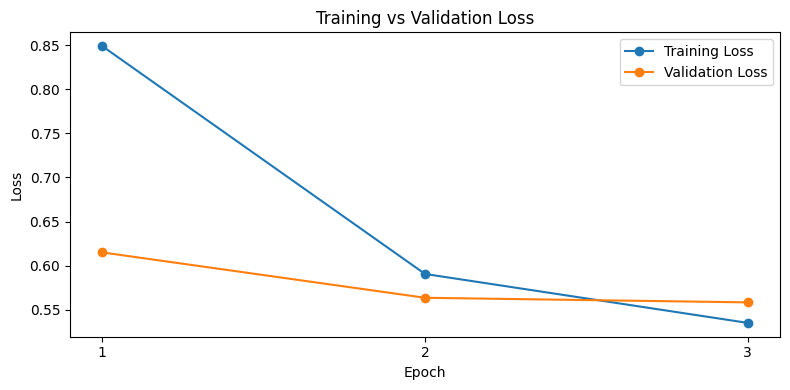

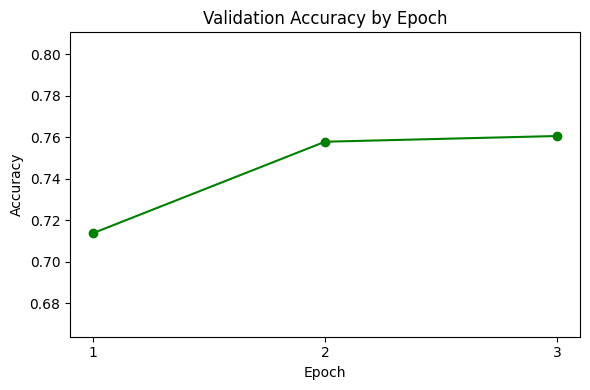

In [24]:
import matplotlib.pyplot as plt
import math
from collections import defaultdict

log_history = trainer.state.log_history

# Build val lists
val_loss, val_acc, epochs = [], [], []
for entry in log_history:
    if 'eval_loss' in entry:
        epoch_num = math.ceil(entry['epoch'])
        if epoch_num not in epochs:
            epochs.append(epoch_num)
            val_loss.append(entry['eval_loss'])
            val_acc.append(entry['eval_accuracy'])

# Build train loss per epoch
epoch_losses = defaultdict(list)
for entry in log_history:
    if 'loss' in entry and 'eval_loss' not in entry and 'train_loss' not in entry:
        epoch_key = math.ceil(entry['epoch'])
        epoch_losses[epoch_key].append(entry['loss'])

sorted_epochs = sorted(epoch_losses.keys())
train_loss_per_epoch = [np.mean(epoch_losses[e]) for e in sorted_epochs]

print("epochs:", epochs)
print("sorted_epochs:", sorted_epochs)
print("val_loss:", val_loss)
print("train_loss_per_epoch:", train_loss_per_epoch)

# Loss curves
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_per_epoch, marker='o', label='Training Loss')
plt.plot(epochs, val_loss,             marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

# Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs, val_acc, marker='o', color='green')
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(max(0, min(val_acc) - 0.05), min(1.0, max(val_acc) + 0.05))
plt.tight_layout()
plt.show()

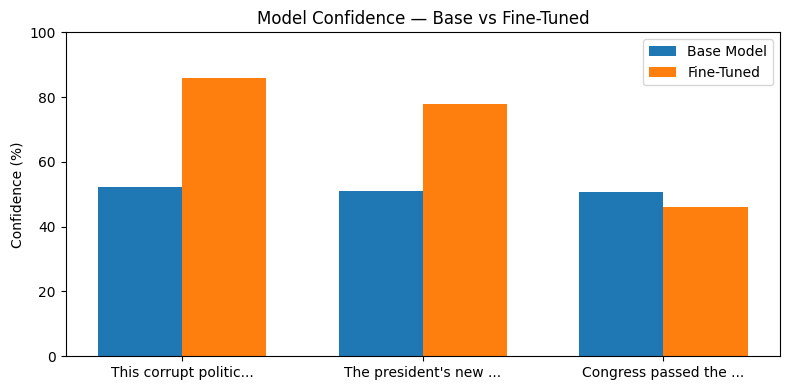

In [25]:
# Base vs Fine-Tuned Confidence
sample_texts = [
    "This corrupt politician is stealing all of our money!",
    "The president's new bill will really help our community.",
    "Congress passed the spending bill today."
]
 
base_conf, ft_conf, short_labels = [], [], []
for text in sample_texts:
    base_conf.append(base_classifier(text)[0]['score'] * 100)
    ft_conf.append(fine_tuned_classifier(text)[0]['score'] * 100)
    short_labels.append(text[:20] + "...")
 
x = np.arange(len(sample_texts))
width = 0.35
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, base_conf, width, label='Base Model')
ax.bar(x + width/2, ft_conf,   width, label='Fine-Tuned')
ax.set_title('Model Confidence — Base vs Fine-Tuned')
ax.set_ylabel('Confidence (%)')
ax.set_xticks(x)
ax.set_xticklabels(short_labels)
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

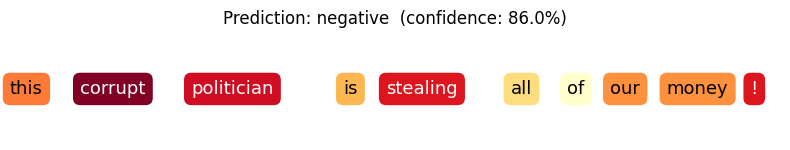

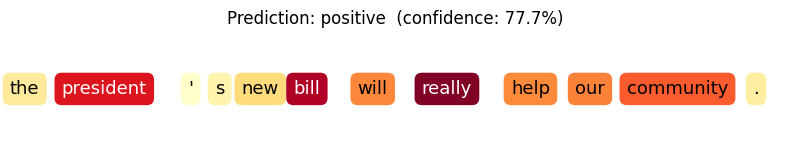

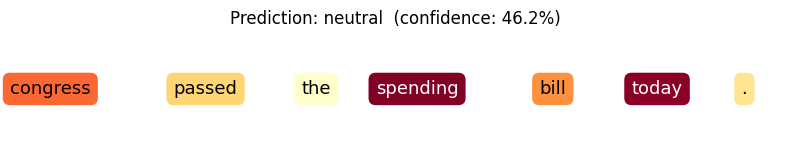

In [26]:
def get_saliency(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
 
    embedding_layer = model.distilbert.embeddings
    captured = {}
 
    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output
 
    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()
 
    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()
 
    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label  = id2label[predicted_class]
    score  = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()
 
    return tokens, saliency, label, score
 
 
def plot_saliency(text, model, tokenizer, device):
    tokens, saliency, label, score = get_saliency(text, model, tokenizer, device)
    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)
 
    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')
 
    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15
 
    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'Prediction: {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
 
 
plot_saliency("This corrupt politician is stealing all of our money!", model, tokenizer, device)
plot_saliency("The president's new bill will really help our community.", model, tokenizer, device)
plot_saliency("Congress passed the spending bill today.", model, tokenizer, device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


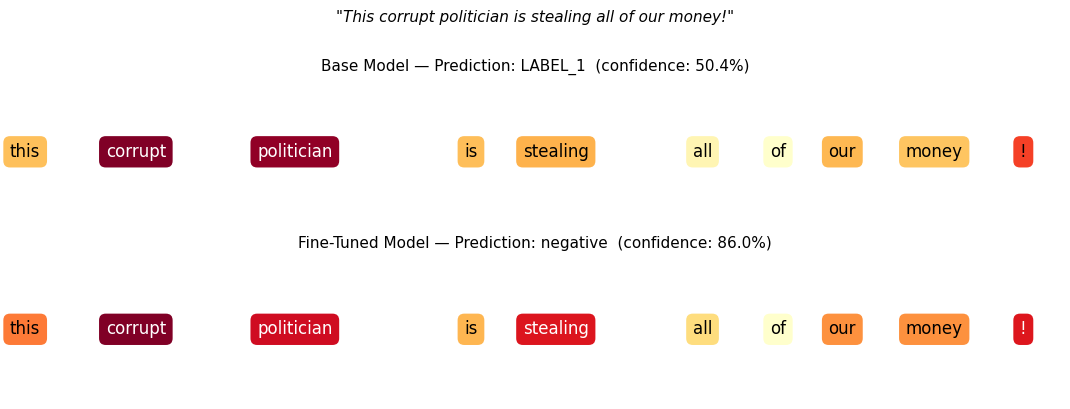

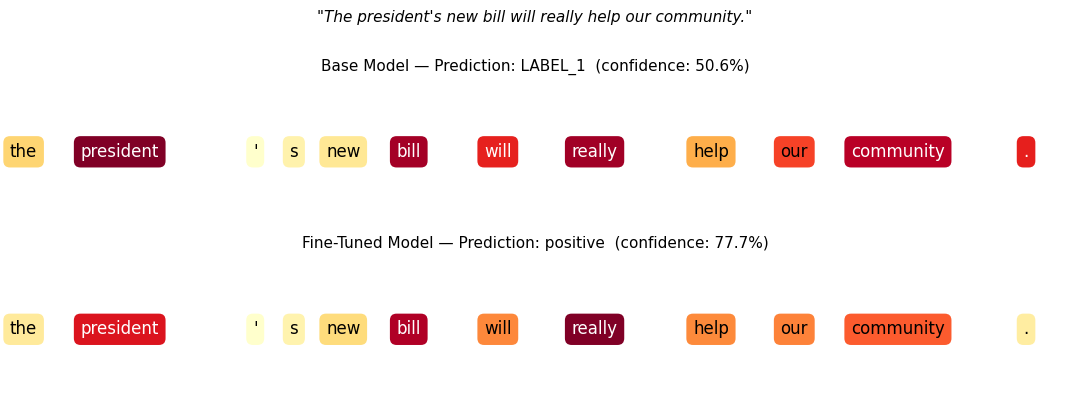

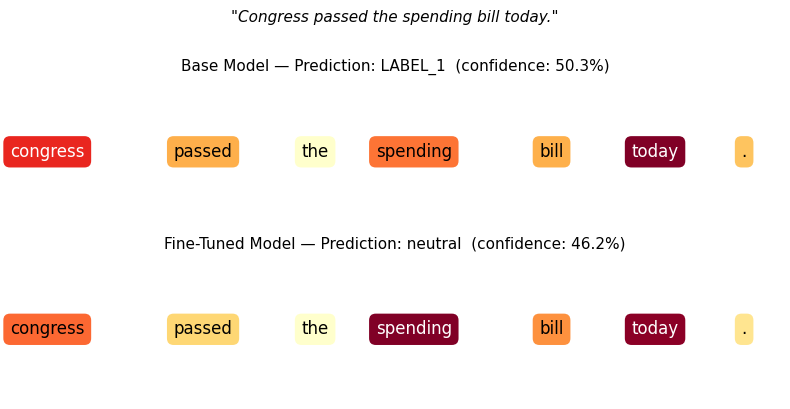

In [27]:
from transformers import AutoModelForSequenceClassification as AMSC
 
base_model_sal = AMSC.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
base_id2label  = {0: "LABEL_0", 1: "LABEL_1"}
 
 
def get_saliency_generic(text, model, tokenizer, device, id2label_map):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
 
    embedding_layer = model.distilbert.embeddings
    captured = {}
 
    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output
 
    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()
 
    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()
 
    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label  = id2label_map[predicted_class]
    score  = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()
 
    return tokens, saliency, label, score
 
 
def plot_saliency_comparison(text, fine_tuned_model, base_model, tokenizer, device):
    fig, axes = plt.subplots(2, 1, figsize=(max(8, len(text.split()) * 1.2), 4))
    fig.suptitle(f'"{text}"', fontsize=11, style='italic', y=1.01)
 
    configs = [
        (base_model,       base_id2label, "Base Model"),
        (fine_tuned_model, id2label,      "Fine-Tuned Model"),
    ]
 
    for ax, (mdl, lbl_map, title) in zip(axes, configs):
        tokens, saliency, label, score = get_saliency_generic(text, mdl, tokenizer, device, lbl_map)
        tokens   = tokens[1:-1]
        saliency = saliency[1:-1]
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)
 
        ax.axis('off')
        cmap = plt.get_cmap("YlOrRd")
        x = 0
        for token, sal in zip(tokens, saliency):
            color = cmap(sal)
            ax.text(x, 0.5, token, ha='left', va='center', fontsize=12,
                    bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                    color='black' if sal < 0.7 else 'white')
            x += len(token) * 0.13 + 0.15
 
        ax.set_xlim(0, x)
        ax.set_ylim(0, 1)
        ax.set_title(f'{title} — Prediction: {label}  (confidence: {score:.1%})', fontsize=11, pad=8)
 
    plt.tight_layout()
    plt.show()
 
 
plot_saliency_comparison("This corrupt politician is stealing all of our money!", model, base_model_sal, tokenizer, device)
plot_saliency_comparison("The president's new bill will really help our community.", model, base_model_sal, tokenizer, device)
plot_saliency_comparison("Congress passed the spending bill today.", model, base_model_sal, tokenizer, device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting fine-tuned embeddings...
Extracting base model embeddings...
Done.
Running t-SNE on fine-tuned embeddings...
Running t-SNE on base embeddings...
Done.


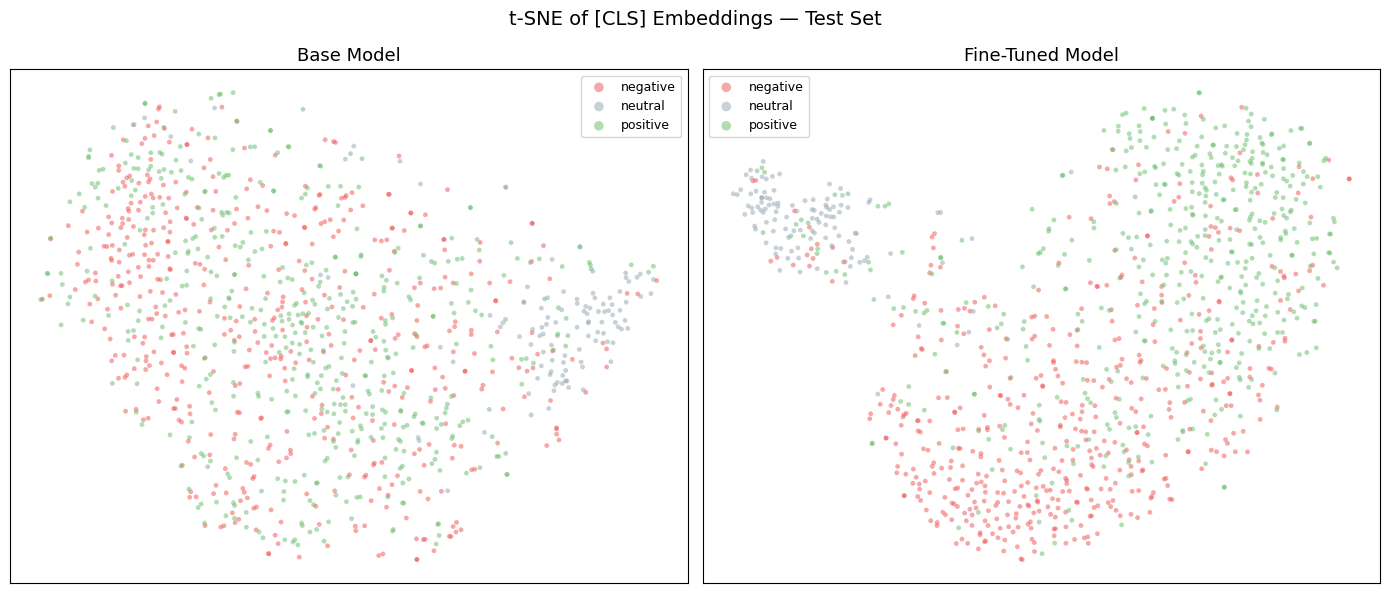

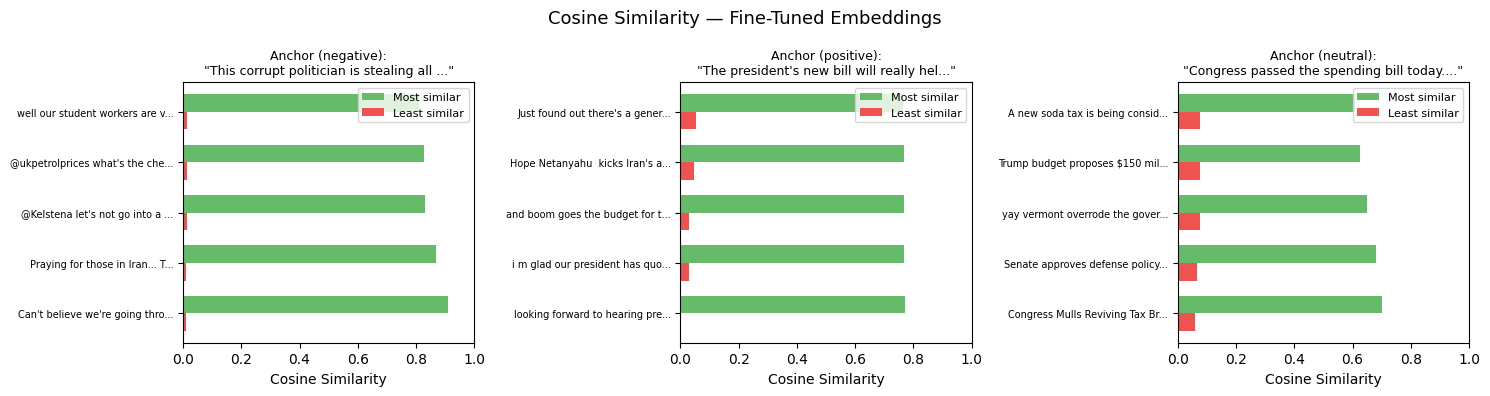

In [29]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
 
def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=128, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)
 
 
base_model_emb = AMSC.from_pretrained(
    "distilbert-base-uncased", num_labels=2, output_hidden_states=True
).to(device)
model.config.output_hidden_states = True
 
texts_test  = test_df["text"].tolist()
labels_test = test_df["sentiment_str"].tolist()
 
print("Extracting fine-tuned embeddings...")
ft_embeddings   = get_cls_embeddings(texts_test, model, tokenizer, device)
print("Extracting base model embeddings...")
base_embeddings = get_cls_embeddings(texts_test, base_model_emb, tokenizer, device)
print("Done.")
 
 
def run_tsne(embeddings):
    pca     = PCA(n_components=50, random_state=42)
    reduced = pca.fit_transform(embeddings)
    tsne    = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
    return tsne.fit_transform(reduced)
 
print("Running t-SNE on fine-tuned embeddings...")
ft_2d   = run_tsne(ft_embeddings)
print("Running t-SNE on base embeddings...")
base_2d = run_tsne(base_embeddings)
print("Done.")
 
label_colors = {"negative": "#ef5350", "neutral": "#90a4ae", "positive": "#66bb6a"}
label_array  = np.array(labels_test)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in zip(axes, [base_2d, ft_2d], ["Base Model", "Fine-Tuned Model"]):
    for sentiment, color in label_colors.items():
        mask = label_array == sentiment
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=sentiment, alpha=0.5, s=12, edgecolors='none')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=9)
fig.suptitle("t-SNE of [CLS] Embeddings — Test Set", fontsize=14)
plt.tight_layout()
plt.show()
 
# Cosine Similarity Bar Chart
anchors = {
    "negative": "This corrupt politician is stealing all of our money!",
    "positive": "The president's new bill will really help our community.",
    "neutral":  "Congress passed the spending bill today.",
}
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sentiment, anchor_text) in zip(axes, anchors.items()):
    anchor_emb = get_cls_embeddings([anchor_text], model, tokenizer, device)
    sims       = cosine_similarity(anchor_emb, ft_embeddings)[0]
 
    ranked   = np.argsort(sims)[::-1]
    top5_idx = [i for i in ranked if texts_test[i] != anchor_text][:5]
    bot5_idx = ranked[-5:][::-1]
 
    y      = np.arange(5)
    height = 0.35
 
    ax.barh(y + height/2, sims[top5_idx], height, label='Most similar',  color='#66bb6a')
    ax.barh(y - height/2, sims[bot5_idx], height, label='Least similar', color='#ef5350')
    ax.set_yticks(y)
    ax.set_yticklabels([f"{texts_test[i][:30]}..." for i in top5_idx], fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Cosine Similarity')
    ax.set_title(f'Anchor ({sentiment}):\n"{anchor_text[:40]}..."', fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle("Cosine Similarity — Fine-Tuned Embeddings", fontsize=13)
plt.tight_layout()
plt.show()